# Principal Component Analysis (PCA)

## Overview

**Principal Component Analysis** is the most widely used dimensionality reduction technique in machine learning and data analysis. PCA finds the directions of maximum variance in high-dimensional data and projects it onto a lower-dimensional subspace — preserving as much information as possible while discarding noise and redundancy.

PCA is used for visualization, noise reduction, feature compression, and as a preprocessing step before downstream modeling.

---

## Intuition

High-dimensional data often lies near a lower-dimensional structure. PCA identifies the axes (principal components) along which the data varies most. Projecting onto the first $k$ components retains the $k$ most informative directions and discards the rest.

---

## Algorithm

Given a data matrix $X \in \mathbb{R}^{n \times p}$:

**1. Center the data:**
$$\tilde{X} = X - \bar{\mathbf{x}}$$

**2. Compute the covariance matrix:**
$$\Sigma = \frac{1}{n-1} \tilde{X}^\top \tilde{X}$$

**3. Eigendecomposition:**
$$\Sigma \mathbf{v}_j = \lambda_j \mathbf{v}_j$$

**4. Sort by descending eigenvalue** and retain the top $k$ eigenvectors.

**5. Project:**
$$Z = \tilde{X} V_k$$

where $V_k \in \mathbb{R}^{p \times k}$ is the matrix of top $k$ eigenvectors.

---

## Explained Variance

Each eigenvalue $\lambda_j$ represents the variance captured by the $j$-th component. The **explained variance ratio** tells us the fraction of total variance retained:

$$\text{EVR}_j = \frac{\lambda_j}{\sum_{i=1}^{p} \lambda_i}$$

A **scree plot** displays eigenvalues in descending order and helps identify the "elbow" — the point where adding more components yields diminishing returns.

---

## Reconstruction

Data can be approximately reconstructed from the reduced representation:

$$\hat{X} = Z V_k^\top + \bar{\mathbf{x}}$$

The **reconstruction error** is zero only when all $p$ components are retained.

---

## Key Properties

| Property | Detail |
|---|---|
| **Type** | Unsupervised, linear dimensionality reduction |
| **Components** | Orthogonal, ordered by variance explained |
| **Input** | Requires mean-centered (and ideally standardized) data |
| **Output** | Uncorrelated features in the projected space |
| **Limitation** | Captures only linear structure |

 EXPERIMENT 1 — Explained Variance (Iris)


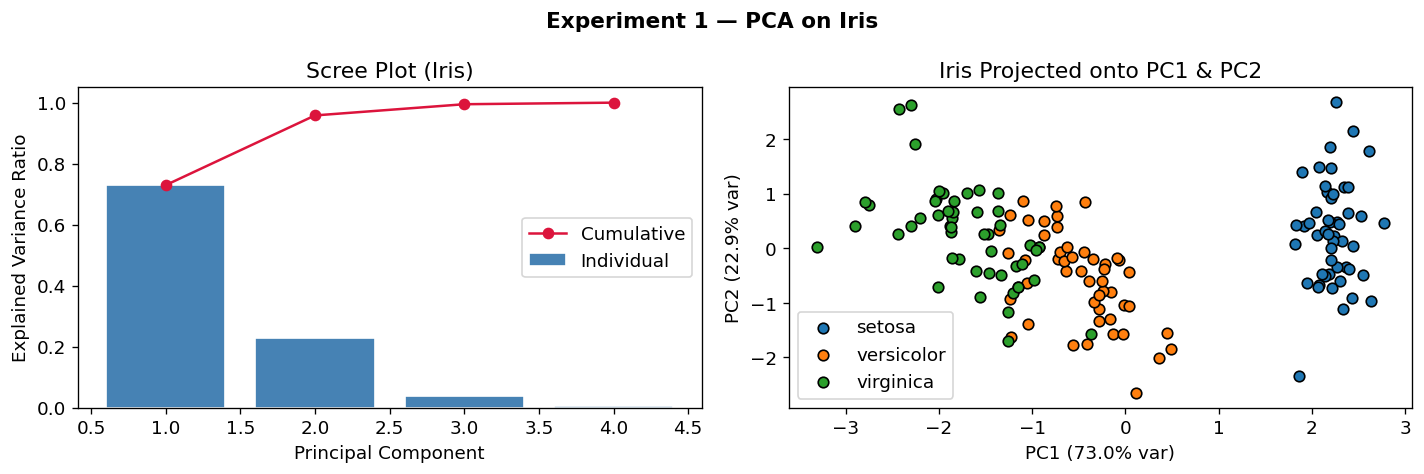

PC1 explains: 72.96%
PC2 explains: 22.85%
PC1+PC2 cumulative: 95.81%

 EXPERIMENT 2 — Reconstruction Error vs Components


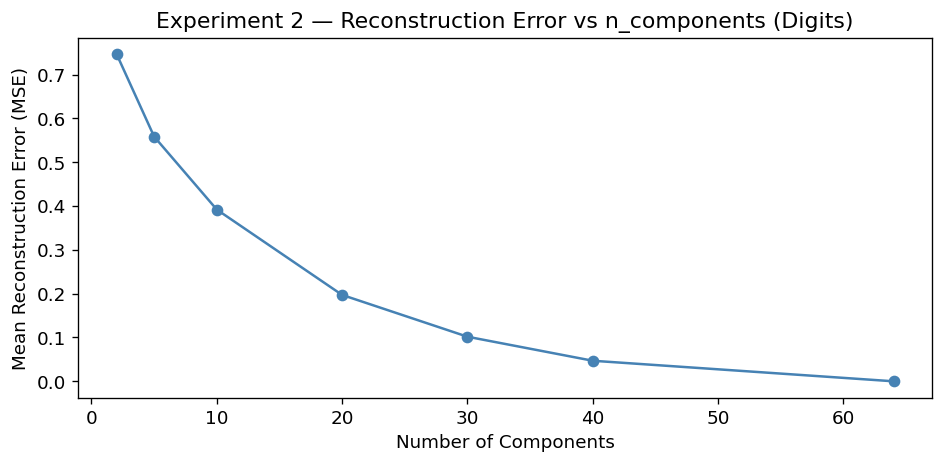

Components → MSE:
    2 components: 0.7473
    5 components: 0.5586
   10 components: 0.3920
   20 components: 0.1972
   30 components: 0.1018
   40 components: 0.0469
   64 components: 0.0000

 EXPERIMENT 3 — Visual Reconstruction (Digits)


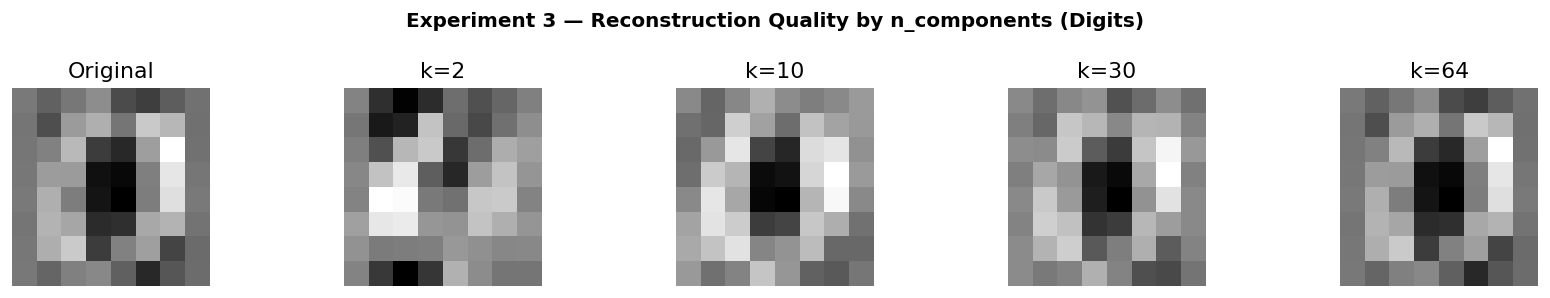

 EXPERIMENT 4 — 2D Projection (Digits)


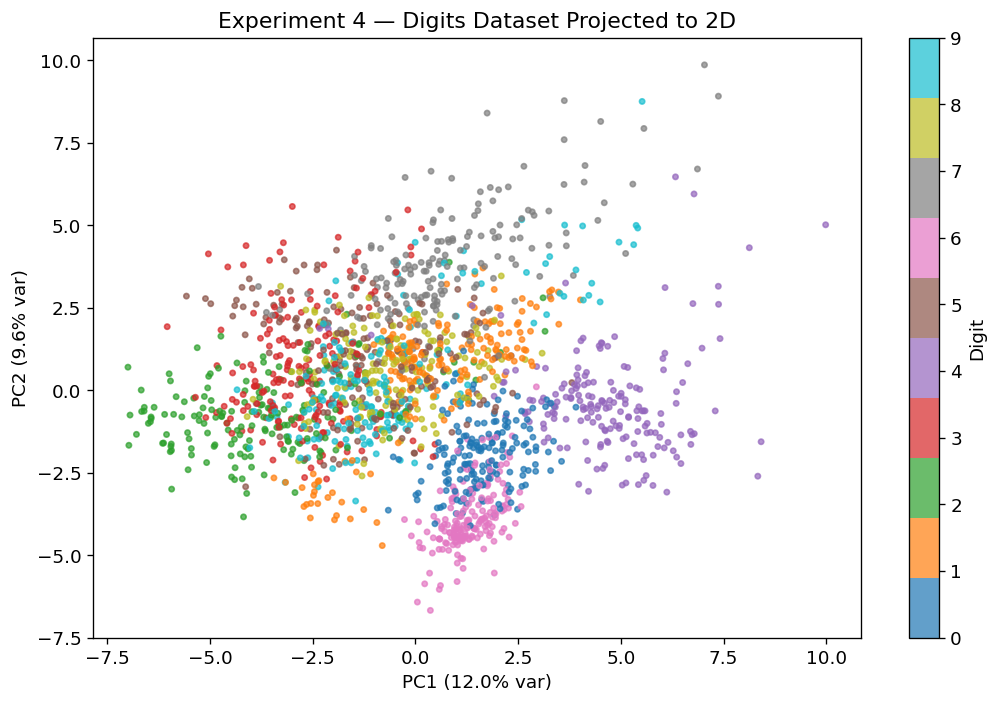

Variance retained (2 components): 21.59%



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage.unsupervised_learning.pca import PCA

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── 1. Scree Plot — Explained Variance ───────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — Explained Variance (Iris)")
print("=" * 55)

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

pca_full = PCA(n_components=4)
pca_full.fit(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 5), pca_full.explained_variance_ratio_,
            color="steelblue", edgecolor="white", label="Individual")
axes[0].plot(range(1, 5), np.cumsum(pca_full.explained_variance_ratio_),
             marker="o", color="crimson", label="Cumulative")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot (Iris)")
axes[0].legend()

pca_2d = PCA(n_components=2)
X_proj = pca_2d.fit_transform(X_iris)
for label, name in enumerate(iris.target_names):
    mask = iris.target == label
    axes[1].scatter(X_proj[mask, 0], X_proj[mask, 1],
                    label=name, edgecolors="k", s=40)
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
axes[1].set_title("Iris Projected onto PC1 & PC2")
axes[1].legend()

plt.suptitle("Experiment 1 — PCA on Iris", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"PC1 explains: {pca_full.explained_variance_ratio_[0]:.2%}")
print(f"PC2 explains: {pca_full.explained_variance_ratio_[1]:.2%}")
print(f"PC1+PC2 cumulative: {pca_full.explained_variance_ratio_[:2].sum():.2%}\n")


# ── 2. Effect of n_components on Reconstruction Error ────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Reconstruction Error vs Components")
print("=" * 55)

digits = load_digits()
X_dig = StandardScaler().fit_transform(digits.data)

n_comp_range = [2, 5, 10, 20, 30, 40, 64]
errors = []
for k in n_comp_range:
    pca_k = PCA(n_components=k)
    X_red = pca_k.fit_transform(X_dig)
    X_rec = pca_k.inverse_transform(X_red)
    errors.append(np.mean((X_dig - X_rec) ** 2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_comp_range, errors, marker="o", color="steelblue")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Mean Reconstruction Error (MSE)")
ax.set_title("Experiment 2 — Reconstruction Error vs n_components (Digits)")
plt.tight_layout()
plt.show()
print("Components → MSE:")
for k, e in zip(n_comp_range, errors):
    print(f"  {k:>3} components: {e:.4f}")


# ── 3. Digit Reconstruction ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print(" EXPERIMENT 3 — Visual Reconstruction (Digits)")
print("=" * 55)

component_counts = [2, 10, 30, 64]
sample_idx = 0
fig, axes = plt.subplots(1, len(component_counts) + 1, figsize=(14, 2.5))

axes[0].imshow(X_dig[sample_idx].reshape(8, 8), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for ax, k in zip(axes[1:], component_counts):
    pca_k = PCA(n_components=k)
    X_red = pca_k.fit_transform(X_dig)
    X_rec = pca_k.inverse_transform(X_red)
    ax.imshow(X_rec[sample_idx].reshape(8, 8), cmap="gray")
    ax.set_title(f"k={k}")
    ax.axis("off")

plt.suptitle("Experiment 3 — Reconstruction Quality by n_components (Digits)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 4. 2D Visualization of High-Dimensional Data ─────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — 2D Projection (Digits)")
print("=" * 55)

pca_2d_dig = PCA(n_components=2)
X_dig_proj = pca_2d_dig.fit_transform(X_dig)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_dig_proj[:, 0], X_dig_proj[:, 1],
                     c=digits.target, cmap="tab10", s=10, alpha=0.7)
plt.colorbar(scatter, ax=ax, label="Digit")
ax.set_xlabel(f"PC1 ({pca_2d_dig.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca_2d_dig.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("Experiment 4 — Digits Dataset Projected to 2D")
plt.tight_layout()
plt.show()
print(f"Variance retained (2 components): "
      f"{pca_2d_dig.explained_variance_ratio_.sum():.2%}\n")